## Imports

This section loads the required libraries.

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Dataset paths

This section defines the training and test directories.

In [2]:
data_dir = Path("../data/raw/fer2013")
train_dir = data_dir / "train"
test_dir = data_dir / "test"

train_classes = sorted([f.name for f in train_dir.iterdir() if f.is_dir()])
test_classes = sorted([f.name for f in test_dir.iterdir() if f.is_dir()])

print("Train classes:", train_classes)
print("Test classes:", test_classes)

Train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## HOG settings

This section defines the HOG parameters.

In [3]:
image_size = (48, 48)
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)
block_norm = "L2-Hys"

print("Image size:", image_size)
print("Orientations:", orientations)
print("Pixels per cell:", pixels_per_cell)
print("Cells per block:", cells_per_block)
print("Block norm:", block_norm)

Image size: (48, 48)
Orientations: 9
Pixels per cell: (8, 8)
Cells per block: (2, 2)
Block norm: L2-Hys


## Feature extraction functions

This section defines image loading and HOG feature extraction.

In [4]:
def load_grayscale_image(image_path, image_size=(48, 48)):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, image_size)
    return image


def extract_hog_features(
    image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
):
    features = hog(
        image,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm=block_norm,
        visualize=False,
        feature_vector=True
    )
    return features.astype("float32")

## Training feature extraction

This section extracts HOG features from the training images.

In [5]:
X_train = []
y_train = []

for class_name in train_classes:
    class_path = train_dir / class_name
    image_paths = list(class_path.glob("*"))

    for image_path in image_paths:
        image = load_grayscale_image(image_path, image_size=image_size)
        features = extract_hog_features(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm
        )
        X_train.append(features)
        y_train.append(class_name)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Feature length:", X_train.shape[1])

X_train shape: (28709, 900)
y_train shape: (28709,)
Feature length: 900


## Test feature extraction

This section extracts HOG features from the test images.

In [6]:
X_test = []
y_test = []
test_image_paths = []

for class_name in test_classes:
    class_path = test_dir / class_name
    image_paths = list(class_path.glob("*"))

    for image_path in image_paths:
        image = load_grayscale_image(image_path, image_size=image_size)
        features = extract_hog_features(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm
        )
        X_test.append(features)
        y_test.append(class_name)
        test_image_paths.append(image_path)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Stored test image paths:", len(test_image_paths))

X_test shape: (7178, 900)
y_test shape: (7178,)
Stored test image paths: 7178


## Model training

This section trains the HOG + SVM model.

In [7]:
hog_svm = LinearSVC(random_state=42, max_iter=10000)
hog_svm.fit(X_train, y_train)

print("Model training is complete.")

Model training is complete.


## Prediction and evaluation

This section generates predictions and evaluates the model.

In [8]:
y_pred = hog_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.4338


In [9]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:

              precision    recall  f1-score   support

       angry     0.3503    0.2589    0.2977       958
     disgust     0.5294    0.1622    0.2483       111
        fear     0.3207    0.1816    0.2319      1024
       happy     0.5185    0.7751    0.6213      1774
     neutral     0.3794    0.4144    0.3961      1233
         sad     0.3277    0.2478    0.2822      1247
    surprise     0.5109    0.5620    0.5352       831

    accuracy                         0.4338      7178
   macro avg     0.4195    0.3717    0.3733      7178
weighted avg     0.4101    0.4338    0.4093      7178



## Confusion matrix

This section shows the class-wise prediction results.

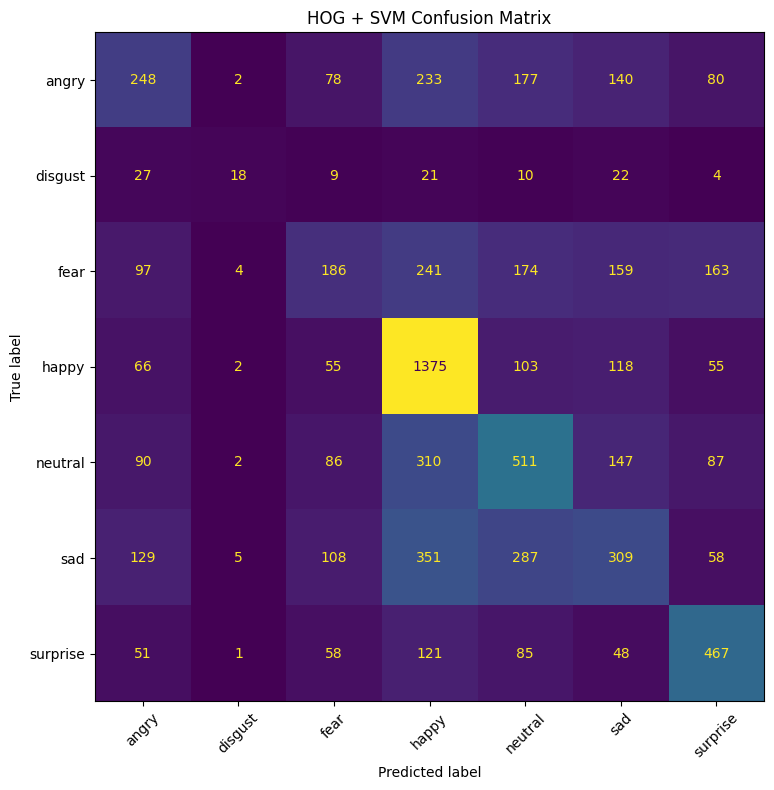

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=test_classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("HOG + SVM Confusion Matrix")
plt.tight_layout()
plt.show()

## Prediction summary

This section shows a few sample predictions.

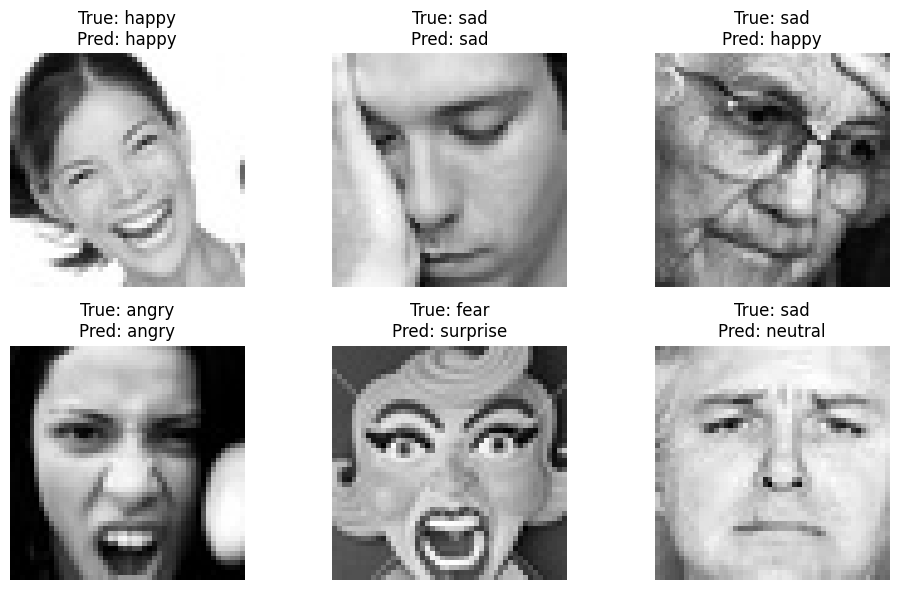

In [11]:
sample_indices = np.random.choice(len(X_test), size=6, replace=False)

plt.figure(figsize=(10, 6))

for i, idx in enumerate(sample_indices):
    image = load_grayscale_image(test_image_paths[idx], image_size=image_size)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observation

The HOG + SVM model shows a clear improvement over the LBP baseline, with higher accuracy and better class separation. The model performs well for classes such as happy, neutral, and surprise, while performance remains lower for classes like fear and disgust. The confusion matrix indicates that misclassification still occurs between similar expressions, but predictions are more distributed across classes compared to LBP.

## Report note

The HOG + SVM model is used as an improved traditional feature-based approach for facial emotion classification. Compared to LBP, HOG captures gradient-based structural features, leading to better performance and reduced bias towards a single class. However, the model still struggles with subtle and visually similar emotions, indicating the limitations of handcrafted features and the need for more expressive deep learning models.